# Unit 6: 高级 BCI 应用 - SSVEP 脑机接口

## 学习目标
- 理解 SSVEP（稳态视觉诱发电位）的原理与应用场景
- 掌握基于 FFT 的 SSVEP 频率识别算法
- 实现完整的视觉刺激生成与 BCI 决策流水线
- 构建 2-class SSVEP BCI 原型系统
- 了解评估 BCI 性能的关键指标（准确率、ITR）

## 核心概念

### SSVEP 原理
**Steady-State Visual Evoked Potential（稳态视觉诱发电位）** 是指当人眼注视特定频率闪烁的视觉刺激时，大脑枕叶视觉皮层会产生与该刺激频率相同的周期性电信号响应。

关键特征：
- 信号频率与闪烁频率**完全一致**
- 主要出现在 **枕叶电极（O1, O2, Oz, Pz）**
- 信噪比高，易于检测
- 不需要训练，即插即用

### SSVEP BCI 系统架构
```text
视觉刺激（频率 f1, f2, ...）
        │
        ▼
用户注视目标 → 枕叶产生 SSVEP 响应
        │
        ▼
EEG 采集（OpenBCI Cyton）
        │
        ▼
信号预处理（滤波、去噪）
        │
        ▼
频率分析（FFT / CCA）
        │
        ▼
分类决策（最大频率功率）
        │
        ▼
输出命令
```

### 频率识别方法
1. **FFT 功率比较**：计算各目标频率处的功率，取最大值
2. **CCA（典型相关分析）**：更鲁棒的方法，考虑谐波成分
3. **FBCCA**：Filter Bank CCA，结合多个频带

## 1. 环境准备

In [14]:
import time
from typing import Tuple, List, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

print("Modules imported successfully.")

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

Modules imported successfully.


## 2. 视觉刺激生成器

In [ ]:
class VisualStimulusGenerator:
    """
    SSVEP 视觉刺激生成器
    
    使用屏幕刷新率（通常 60 Hz）生成不同频率的闪烁方块。
    闪烁通过翻转背景颜色实现（黑 <-> 白）。
    黑+白算作一个周期
    """
    
    def __init__(self, refresh_rate: float = 60.0):
        """
        Args:
            refresh_rate: 显示器刷新率（Hz），常见 60 Hz
        """
        self.refresh_rate = refresh_rate  # 显示器刷新率（Hz）
        
    def generate_stimulus_sequence(
        self,
        target_freq: float,  # 目标闪烁频率（Hz）
        duration: float = 5.0
    ) -> np.ndarray:
        """
        生成闪烁刺激序列
        
        Args:
            target_freq: 目标闪烁频率（Hz）
            duration: 刺激持续时间（秒）
            这种方法按完整周期对齐目标频率，但不保证黑白等时长。
            当每半周期不是整数帧时，会产生非 50% 占空比。
        
        Returns:
            0/1 序列，0 表示黑色，1 表示白色
        """
        # 刺激持续时间总（显示器帧）
        n_frames = int(duration * self.refresh_rate)  
        # 每个半周期的持续的显示器帧数
        frames_per_half_cycle = self.refresh_rate / (2 * target_freq)
        
        sequence = np.zeros(n_frames)
        for i in range(n_frames):
            # 根据半周期位置决定是否翻转
            phase = (i % (2 * frames_per_half_cycle)) / frames_per_half_cycle
            sequence[i] = 1 if phase < 1 else 0 # 前半周期为白色1，后半周期为黑色0
        return sequence
    
    def get_available_frequencies(self) -> List[float]:
        """
        获取当前刷新率下可用的闪烁频率
        可用频率必须能被刷新率整除
        Python 的 round 有银行家舍入特性
        口诀：四舍六入，五取偶
        小数部分 < 0.5 ：舍去
        小数部分 > 0.5 ：进位
        小数部分 = 0.5 ：取最近的偶数
        round(2.4)   # 2
        round(2.6)   # 3
        round(2.5)   # 2
        """
        freqs = []
        for f in range(6, 31):  # 6-30 Hz
            # 计算半周期的持续的显示器帧数
            if self.refresh_rate % (2 * f) == 0 or abs(self.refresh_rate / (2 * f) - round(self.refresh_rate / (2 * f))) < 0.01:
                freqs.append(float(f))
        return freqs


# 创建刺激生成器
stim_gen = VisualStimulusGenerator(refresh_rate=60.0)
available = stim_gen.get_available_frequencies()
print(f"Available flicker frequencies (60 Hz display): {available}")

# 生成两个目标频率的刺激序列
FREQ_LEFT = 10.0   # 左侧目标：10 Hz
# FREQ_RIGHT = 12.0  # 右侧目标：12 Hz

seq_left = stim_gen.generate_stimulus_sequence(FREQ_LEFT, duration=2.0)
seq_right = stim_gen.generate_stimulus_sequence(FREQ_RIGHT, duration=2.0)

print(f"\n10 Hz sequence length: {len(seq_left)} frames ({len(seq_left)/60:.2f}s)")
print(f"12 Hz sequence length: {len(seq_right)} frames ({len(seq_right)/60:.2f}s)")

Available flicker frequencies (60 Hz display): [6.0, 10.0, 15.0, 30.0]

10 Hz sequence length: 120 frames (2.00s)
12 Hz sequence length: 120 frames (2.00s)


## 3. 模拟 SSVEP 信号

模拟包含 SSVEP 响应的 EEG 信号，用于演示和测试分类算法。

In [ ]:
def simulate_ssvep_response(
    stimulus_freq: float,
    sfreq: float = 250.0,
    duration: float = 5.0,
    snr_db: float = 5.0,
    n_channels: int = 2
) -> np.ndarray:
    """
    模拟 SSVEP 响应信号
    
    SSVEP 响应包含：
    - 基频成分（刺激频率）
    - 谐波成分（2f, 3f）
    - 背景 EEG 噪声
    
    Args:
        stimulus_freq: 刺激频率（Hz）
        sfreq: EEG 采样率
        duration: 持续时间
        snr_db: 信噪比（dB）Signal-to-Noise Ratio
        n_channels: 通道数
    
    Returns:
        (n_channels, n_samples) 模拟 SSVEP 信号
    """
    np.random.seed(int(stimulus_freq * 100))
    n_samples = int(duration * sfreq)
    t = np.arange(n_samples) / sfreq
    data = np.zeros((n_channels, n_samples))
    
    # SSVEP 振幅（枕叶通道较强）
    # 变量 = 值1 if 条件 else 值2
    channel_weights = [1.0, 0.7] if n_channels >= 2 else [1.0]
    
    for ch in range(n_channels):
        w = channel_weights[ch] if ch < len(channel_weights) else 0.3
        
        # 诱发 SSVEP 响应信号
        ssvep = (
            w * 8 * np.sin(2 * np.pi * stimulus_freq * t) # 基频成分
            + w * 3 * np.sin(2 * np.pi * 2 * stimulus_freq * t) # 2f 谐波成分
            + w * 1.5 * np.sin(2 * np.pi * 3 * stimulus_freq * t) # 3f 谐波成分
        )
        
        # 背景 EEG 噪声
        background = (
            5 * np.sin(2 * np.pi * 10 * t)
            + 3 * np.sin(2 * np.pi * 6 * t)
            + 2 * np.sin(2 * np.pi * 20 * t)
        )

        # 根据 信噪比 SNR(Signal-to-Noise Ratio) 调整噪声
        # 从给定的 snr_db 反推噪声功率
        signal_power = np.var(ssvep)
        noise_power = signal_power / (10 ** (snr_db / 10))

        data[ch] += ssvep + background
        data[ch] += np.random.randn(n_samples) * np.sqrt(noise_power)
    
    return data


# 生成两个目标的 SSVEP 响应
print("Generating simulated SSVEP responses...")
ssvep_10hz = simulate_ssvep_response(FREQ_LEFT, sfreq=250, duration=5, snr_db=5)
ssvep_12hz = simulate_ssvep_response(FREQ_RIGHT, sfreq=250, duration=5, snr_db=5)

print(f"SSVEP@10Hz shape: {ssvep_10hz.shape}")
print(f"SSVEP@12Hz shape: {ssvep_12hz.shape}")

Generating simulated SSVEP responses...
SSVEP@10Hz shape: (2, 1250)
SSVEP@12Hz shape: (2, 1250)


## 4. SSVEP 频率识别算法

In [12]:
class SSVEPClassifier:
    """
    SSVEP 频率分类器
    
    使用 FFT 功率谱方法识别用户注视的目标频率。
    """
    
    def __init__(
        self,
        target_frequencies: List[float],
        sfreq: float = 250.0,
        bandwidth: float = 1.0,
        include_harmonics: bool = True,
        n_harmonics: int = 3
    ):
        """
        Args:
            target_frequencies: 目标频率列表（如 [10, 12]）
            sfreq: EEG 采样频率
            bandwidth: 频率检测带宽（Hz）
            include_harmonics: 是否包含谐波成分
            n_harmonics: 考虑谐波的最大数量
        """
        self.target_frequencies = target_frequencies
        self.sfreq = sfreq
        self.bandwidth = bandwidth
        self.include_harmonics = include_harmonics
        self.n_harmonics = n_harmonics
    
    def compute_frequency_power(
        self,
        data: np.ndarray,
        target_freq: float
    ) -> float:
        """
        计算信号在目标频率（及谐波）处的总功率
        
        Args:
            data: 1D EEG 信号
            target_freq: 目标频率
        
        Returns:
            float: 该频率处的总功率（基频 +谐波）
        """
        n = len(data) # 样本数
        
        # 使用 FFT 计算频谱
        from scipy.fft import fft, fftfreq
        fft_values = fft(data * np.hanning(n))  # 加汉宁窗减少泄漏
        freqs = fftfreq(n, d=1.0 / self.sfreq)

        power_base = 0.0
        power_harmonic = 0.0
        
        # 取出正频率部分
        pos_mask = freqs > 0
        freqs = freqs[pos_mask]
        power = np.abs(fft_values[pos_mask]) ** 2
        
        # 基频功率
        # 选出 target_freq ± bandwidth/2 范围内的所有频率点
        # [target_freq - bandwidth/2, target_freq + bandwidth/2]
        freq_mask = np.abs(freqs - target_freq) <= self.bandwidth / 2
        power_base = np.sum(power[freq_mask])
        
        # 谐波功率
        if self.include_harmonics:
            for h in range(2, self.n_harmonics + 1):
                harmonic_freq = target_freq * h
                if harmonic_freq < self.sfreq / 2:
                    harm_mask = np.abs(freqs - harmonic_freq) <= self.bandwidth / 2
                    power_harmonic += np.sum(power[harm_mask]) / (h ** 2)  # 谐波加权
        
        return float(power_base + power_harmonic)
    
    def predict(
        self,
        data: np.ndarray
    ) -> Tuple[int, float, Dict[float, float]]:
        """
        预测用户注视的目标
        
        Args:
            data: (n_channels, n_samples) EEG 数据
        
        Returns:
            best_idx: 最可能的目标索引
            confidence: 置信度（0-1）
            all_powers: 各目标的功率值
        """
        # 合并所有通道的功率
        all_powers = {}
        
        for freq in self.target_frequencies:
            total = 0
            for ch in range(data.shape[0]):
                # 叠加每个通道在目标频率处的功率值
                total += self.compute_frequency_power(data[ch], freq)
            # 存储每个候选频率的总功率值
            all_powers[freq] = total 
        
        # 选择功率最大的频率
        best_freq = max(all_powers, key=all_powers.get)
        best_idx = self.target_frequencies.index(best_freq)
        
        # 计算置信度
        total_power = sum(all_powers.values())
        confidence = all_powers[best_freq] / total_power if total_power > 0 else 0
        
        return best_idx, confidence, all_powers
    


    def get_full_spectrum(
        self,
        data: np.ndarray,
        channel: int = 0
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        获取功率谱密度 PSD，用于可视化。
        时间窗口长度为 2 秒

        Args:
            data: shape = (n_channels, n_samples)
            channel: 要分析的通道

        Returns:
            freqs: 正频率数组，单位 Hz
            psd: 正频率功率谱密度，单位通常是 信号单位^2/Hz
        """
        freqs, psd = signal.welch(
            data[channel],
            fs=self.sfreq,
            window="hann",
            nperseg=min(int(self.sfreq * 2), data.shape[1]),
            noverlap=None, # 相邻窗口重叠 50%
            scaling="density",
            return_onesided=True, # 只返回正频率部分
        )

        return freqs, psd


# 创建分类器
classifier = SSVEPClassifier(
    target_frequencies=[FREQ_LEFT, FREQ_RIGHT],
    sfreq=250,
    bandwidth=1.0,
    include_harmonics=True,
    n_harmonics=3
)

# 测试：10 Hz 刺激的数据应被识别为 10 Hz
idx_10, conf_10, powers_10 = classifier.predict(ssvep_10hz)
idx_12, conf_12, powers_12 = classifier.predict(ssvep_12hz)

print("=== Classification Results ===")
print(f"True 10 Hz -> Predicted: {classifier.target_frequencies[idx_10]} Hz "
      f"(confidence: {conf_10:.3f})")
print(f"  Powers: {powers_10}")

print(f"\nTrue 12 Hz -> Predicted: {classifier.target_frequencies[idx_12]} Hz "
      f"(confidence: {conf_12:.3f})")
print(f"  Powers: {powers_12}")

=== Classification Results ===
True 10 Hz -> Predicted: 10.0 Hz (confidence: 0.999)
  Powers: {10.0: 43022391.630496204, 12.0: 44887.26812739905}

True 12 Hz -> Predicted: 12.0 Hz (confidence: 0.666)
  Powers: {10.0: 7592973.724464529, 12.0: 15141873.498131078}


## 5. 功率谱可视化

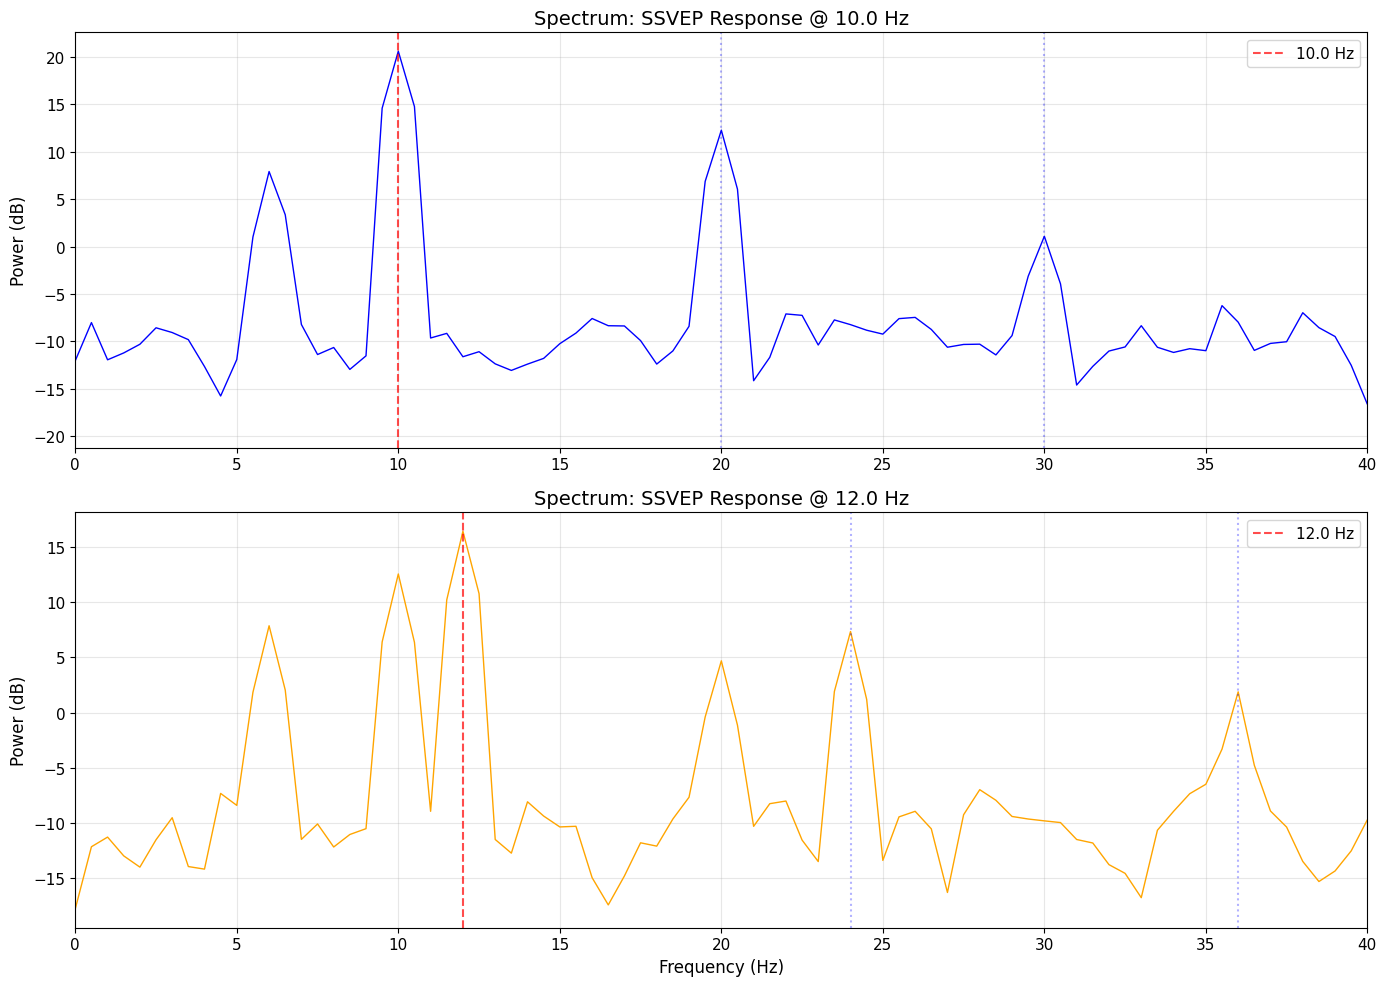

In [18]:
# 查看频谱
freqs_10, power_10 = classifier.get_full_spectrum(ssvep_10hz, channel=0)
freqs_12, power_12 = classifier.get_full_spectrum(ssvep_12hz, channel=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 10 Hz 刺激
axes[0].plot(freqs_10, 10 * np.log10(power_10 + 1e-15), color='blue', linewidth=1)
axes[0].set_title(f'Spectrum: SSVEP Response @ {FREQ_LEFT} Hz', fontsize=14)
axes[0].set_ylabel('Power (dB)', fontsize=12)
axes[0].set_xlim(0, 40)
axes[0].grid(True, alpha=0.3)

# 标注目标频率
for f in classifier.target_frequencies:
    if f != FREQ_LEFT:
        continue
    # 基波
    axes[0].axvline(x=f, color='red', linestyle='--', alpha=0.7, label=f'{f} Hz')
    # 谐波
    for h in range(2, 4):
        axes[0].axvline(x=f * h, color='blue', linestyle=':', alpha=0.3)
axes[0].legend()

# 12 Hz 刺激
axes[1].plot(freqs_12, 10 * np.log10(power_12 + 1e-15), color='orange', linewidth=1)
axes[1].set_title(f'Spectrum: SSVEP Response @ {FREQ_RIGHT} Hz', fontsize=14)
axes[1].set_xlabel('Frequency (Hz)', fontsize=12)
axes[1].set_ylabel('Power (dB)', fontsize=12)
axes[1].set_xlim(0, 40)
axes[1].grid(True, alpha=0.3)

for f in classifier.target_frequencies:
    if f != FREQ_RIGHT:
        continue
    axes[1].axvline(x=f, color='red', linestyle='--', alpha=0.7, label=f'{f} Hz')
    for h in range(2, 4):
        axes[1].axvline(x=f * h, color='blue', linestyle=':', alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. BCI 系统性能评估

In [19]:
def evaluate_ssvep_bci(
    classifier: SSVEPClassifier,
    target_frequencies: List[float],
    n_trials: int = 20,
    trial_duration: float = 5.0, # 每个 trial 的时长
    sfreq: float = 250.0,
    snr_range: Tuple[float, float] = (0, 10)
) -> Dict:
    """
    评估 SSVEP BCI 系统性能
    
    Args:
        classifier: SSVEP 分类器
        target_frequencies: 目标频率列表
        n_trials: 每个频率的 trial 数
        trial_duration: 每个 trial 的时长
        sfreq: 采样率
        snr_range: 信噪比 SNR 范围 (min, max)
    
    Returns:
        评估结果字典
    """
    n_classes = len(target_frequencies)
    confusion_matrix = np.zeros((n_classes, n_classes), dtype=int) # 混淆矩阵
    correct = 0
    total = 0
    confidences = []
    
    # 为每个试次生成不同的信噪比
    snr_values = np.linspace(snr_range[0], snr_range[1], n_trials)
    
    for true_idx, target_freq in enumerate(target_frequencies):
        for trial in range(n_trials):
            # 生成不同 SNR 下的模拟数据
            snr = snr_values[trial]
            # 生成模拟诱发响应数据
            data = simulate_ssvep_response(
                target_freq, sfreq=sfreq,
                duration=trial_duration,
                snr_db=snr
            )
            
            predicted_idx, confidence, _ = classifier.predict(data)
            confidences.append(confidence)
            # 行：真实类别 true label
            # 列：预测类别 predicted label
            confusion_matrix[true_idx, predicted_idx] += 1
            if predicted_idx == true_idx:
                correct += 1 # 统计正确次数
            total += 1       # 统计总次数
    
    accuracy = correct / total if total > 0 else 0
    
    # 计算信息传输率 ITR (bits/trial)
    # itr:每个 trial 的信息量，bits/trial
    # ITR = log2(N) + P*log2(P) + (1-P)*log2((1-P)/(N-1))
    if accuracy > 0 and accuracy < 1:
        itr = (np.log2(n_classes) + 
               accuracy * np.log2(accuracy) + 
               (1 - accuracy) * np.log2((1 - accuracy) / (n_classes - 1)))
    elif accuracy == 1:
        # 如果 4 分类完全正确，每次 trial 最多传递 2 bit
        itr = np.log2(n_classes)
    else:
        itr = 0
    
    # 比特率 (bits/min)
    # 从 bits/trial 转换成 bits/minute
    # 每分钟信息传输率 = 每个 trial 的信息量 × 每分钟能完成多少个 trial
    bits_per_min = itr * (60 / trial_duration)
    
    return {
        'accuracy': accuracy,
        'confusion_matrix': confusion_matrix,
        'mean_confidence': np.mean(confidences),
        'itr_per_trial': itr,
        'bits_per_minute': bits_per_min,
        'total_trials': total,
        'correct': correct
    }


# 运行评估
print("Running BCI performance evaluation...")
results = evaluate_ssvep_bci(
    classifier,
    target_frequencies=[FREQ_LEFT, FREQ_RIGHT],
    n_trials=20,
    trial_duration=5.0,
    sfreq=250,
    snr_range=(0, 10)
)

print("\n" + "=" * 50)
print("BCI Performance Evaluation")
print("=" * 50)
print(f"Accuracy: {results['accuracy']*100:.1f}%")
print(f"Mean Confidence: {results['mean_confidence']:.3f}")
print(f"ITR: {results['itr_per_trial']:.2f} bits/trial")
print(f"Speed: {results['bits_per_minute']:.1f} bits/min")
print(f"Total trials: {results['total_trials']}")
print(f"Correct: {results['correct']}")

# 混淆矩阵
print("\nConfusion Matrix:")
print(results['confusion_matrix'])

Running BCI performance evaluation...

BCI Performance Evaluation
Accuracy: 100.0%
Mean Confidence: 0.833
ITR: 1.00 bits/trial
Speed: 12.0 bits/min
Total trials: 40
Correct: 40

Confusion Matrix:
[[20  0]
 [ 0 20]]


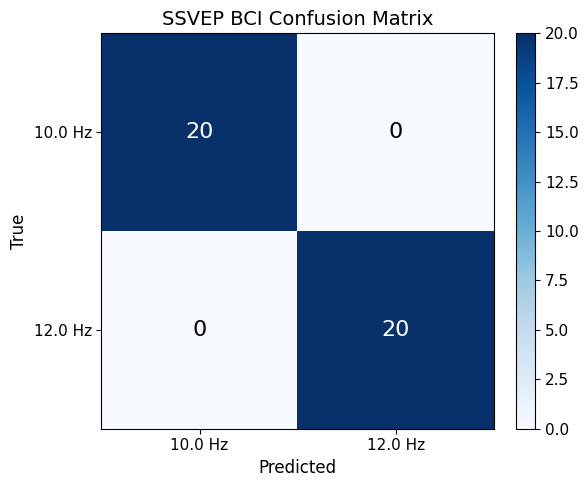

In [ ]:
# 可视化混淆矩阵
# 行：真实类别 true label
# 列：预测类别 predicted label
cm = results['confusion_matrix']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues', aspect='auto')

ax.set_xticks(range(len([FREQ_LEFT, FREQ_RIGHT])))
ax.set_xticklabels([f'{FREQ_LEFT} Hz', f'{FREQ_RIGHT} Hz'])
ax.set_yticks(range(len([FREQ_LEFT, FREQ_RIGHT])))
ax.set_yticklabels([f'{FREQ_LEFT} Hz', f'{FREQ_RIGHT} Hz'])

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('SSVEP BCI Confusion Matrix', fontsize=14)

# 添加数值标注
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', 
               color=color, fontsize=16)

plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 7. 完整 SSVEP BCI 系统类

In [ ]:
class SSVEPBCISystem:
    """
    完整的 SSVEP BCI 系统
    
    整合了：
    - 视觉刺激生成
    - EEG 数据预处理
    - SSVEP 分类
    - 命令输出
    """
    
    def __init__(
        self,
        target_frequencies: List[float],
        target_labels: List[str],
        sfreq: float = 250.0,
        refresh_rate: float = 60.0
    ):
        """
        Args:
            target_frequencies: 各目标的闪烁频率
            target_labels: 各目标的标签/命令
            sfreq: EEG 采样频率
            refresh_rate: 显示器刷新率
        """
        assert len(target_frequencies) == len(target_labels), \
            "Number of frequencies must match number of labels"
        
        self.target_frequencies = target_frequencies
        self.target_labels = target_labels
        self.sfreq = sfreq
        
        # 子系统
        self.stimulus_gen = VisualStimulusGenerator(refresh_rate)
        self.classifier = SSVEPClassifier(
            target_frequencies=target_frequencies,
            sfreq=sfreq,
            bandwidth=1.0,
            include_harmonics=True,
            n_harmonics=3
        )
        
        # 状态
        self.is_running = False # BCI 系统是否正在运行
        self.trial_count = 0   # BCI 系统处理的 trial 数量
        self.correct_count = 0 # BCI 系统正确分类的 trial 数量
    
    def process_trial(
        self,
        eeg_data: np.ndarray,
        true_target_idx: Optional[int] = None
    ) -> Dict:
        """
        处理一个 trial 的数据
        
        Args:
            eeg_data: (n_channels, n_samples) EEG 数据
            true_target_idx: 真实目标索引（用于评估）
        
        Returns:
            包含预测结果的字典
        """
        # 步骤 1: 预处理（带通滤波 3-45 Hz）
        processed = np.copy(eeg_data)
        for ch in range(processed.shape[0]):
            # 设计一个 4 阶 Butterworth 带通滤波器，通带为 3~45 Hz
            # 频率需要除以 Nyquist 频率 self.sfreq / 2，转换成归一化频率
            # output='sos' 表示以二阶节 Second-Order Sections 形式返回滤波器系数，
            # 数值稳定性通常比传统的 b, a 系数形式更好
            sos = signal.butter(4, [3/(self.sfreq/2), 45/(self.sfreq/2)], 
                                     btype='band', output='sos')
            # 对当前通道 processed[ch] 进行零相位带通滤波
            # sosfiltfilt 会先正向滤波再反向滤波，可以避免普通滤波带来的相位延迟
            # 滤波结果重新写回当前通道
            processed[ch] = signal.sosfiltfilt(sos, processed[ch])
        
        # 步骤 2: 分类
        predicted_idx, confidence, powers = self.classifier.predict(processed)
        
        # 步骤 3: 构建结果
        result = {
            'predicted_label': self.target_labels[predicted_idx],
            'predicted_freq': self.target_frequencies[predicted_idx],
            'confidence': confidence,
            'all_powers': powers,
            'correct': (predicted_idx == true_target_idx) if true_target_idx is not None else None
        }
        
        # 更新统计
        self.trial_count += 1
        if result['correct']:
            self.correct_count += 1
        
        return result
    
    def get_statistics(self) -> Dict:
        """
        获取系统运行统计
        """
        return {
            'trials': self.trial_count,
            'accuracy': self.correct_count / self.trial_count if self.trial_count > 0 else 0,
            'correct': self.correct_count
        }


# 创建 2-class BCI 系统
bci = SSVEPBCISystem(
    target_frequencies=[10.0, 12.0],
    target_labels=["LEFT", "RIGHT"],
    sfreq=250.0
)

print("SSVEP BCI System initialized.")
print(f"Target 1: 10 Hz -> Command: 'LEFT'")
print(f"Target 2: 12 Hz -> Command: 'RIGHT'")

SSVEP BCI System initialized.
Target 1: 10 Hz -> Command: 'LEFT'
Target 2: 12 Hz -> Command: 'RIGHT'


## 8. 完整 BCI 实验模拟

In [ ]:
# 模拟运行 30 个 trials
np.random.seed(42)
n_trials = 30
trial_duration = 5.0
results_list = []

print("Running simulated SSVEP BCI experiment...")
print("-" * 60)

for trial in range(n_trials):
    # 随机选择目标
    true_idx = trial % 2  # 交替
    true_freq = bci.target_frequencies[true_idx]
    
    # 生成模拟 EEG
    snr = np.random.uniform(2, 12)  # 随机 SNR
    eeg_data = simulate_ssvep_response(
        true_freq, sfreq=250, 
        duration=trial_duration, snr_db=snr
    )
    
    # 处理 trial
    result = bci.process_trial(eeg_data, true_target_idx=true_idx)
    results_list.append(result)
    
    # 本次 trial 结果打印
    status = "CORRECT" if result['correct'] else "WRONG"
    print(f"Trial {trial+1:2d}: True={true_freq:.0f}Hz | "
          f"Pred={result['predicted_freq']:.0f}Hz | "
          f"Conf={result['confidence']:.3f} | {status}")

# 打印 BCI 系统运行统计
print("-" * 60)
stats = bci.get_statistics()
print(f"\nFinal Results:")
print(f"  Trials: {stats['trials']}")
print(f"  Accuracy: {stats['accuracy']*100:.1f}%")
print(f"  Correct: {stats['correct']}/{stats['trials']}")

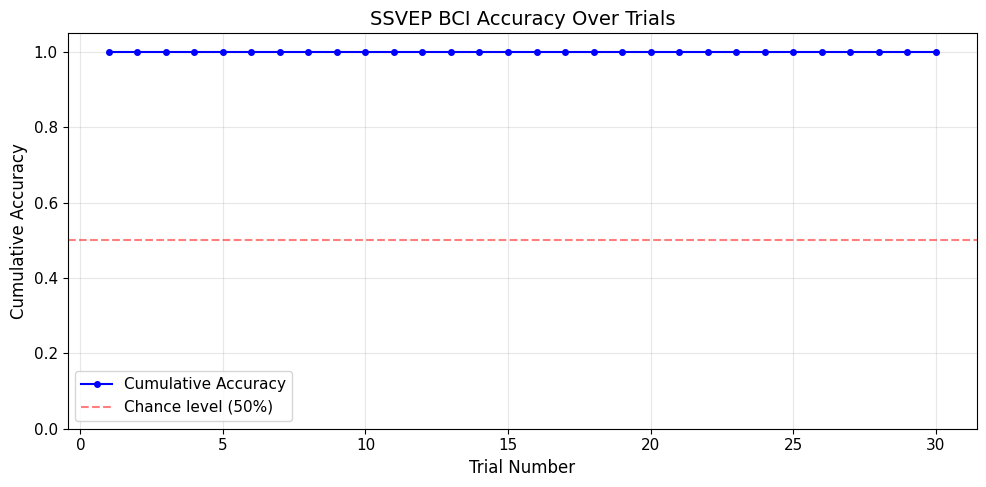

In [24]:
# 准确率随 trials 的变化
cumulative_accuracy = [] # 累计准确率列表
correct_so_far = 0 # 累计正确分类 trial 数量
for i, r in enumerate(results_list):
    if r['correct']:
        correct_so_far += 1
    cumulative_accuracy.append(correct_so_far / (i + 1))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumulative_accuracy) + 1), cumulative_accuracy, 
       'b-o', markersize=4, linewidth=1.5, label='Cumulative Accuracy')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance level (50%)')
ax.set_xlabel('Trial Number', fontsize=12)
ax.set_ylabel('Cumulative Accuracy', fontsize=12)
ax.set_title('SSVEP BCI Accuracy Over Trials', fontsize=14)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. 扩展：4-class SSVEP BCI

In [ ]:
# 4-class 配置
FOUR_FREQS = [10.0, 12.0, 14.0, 15.0]
FOUR_LABELS = ["UP", "DOWN", "LEFT", "RIGHT"]

bci_4class = SSVEPBCISystem(
    target_frequencies=FOUR_FREQS,
    target_labels=FOUR_LABELS,
    sfreq=250.0
)

# 快速评估
results_4 = evaluate_ssvep_bci(
    bci_4class.classifier,
    target_frequencies=FOUR_FREQS,
    n_trials=15,
    trial_duration=5.0,
    sfreq=250,
    snr_range=(2, 12)
)

print("4-Class SSVEP BCI Evaluation:")
print(f"  Accuracy: {results_4['accuracy']*100:.1f}%")
print(f"  ITR: {results_4['itr_per_trial']:.2f} bits/trial")
print(f"  Speed: {results_4['bits_per_minute']:.1f} bits/min")
print(f"  Chance level: {1/len(FOUR_FREQS)*100:.1f}%")

print("\nConfusion Matrix:")
print(results_4['confusion_matrix'])

## 10. 知识点总结

### SSVEP BCI 关键要点
1. **刺激频率选择**：需在显示器刷新率约束下选择，避免谐波重叠
2. **SSVEP 特点**：枕叶最强，含基频和谐波，信噪比高
3. **分类方法**：FFT 功率比较最简单，CCA 更鲁棒
4. **性能指标**：
   - 准确率（Accuracy）
   - 信息传输率 ITR（bits/trial）
   - 比特率（bits/min）

### ITR 公式
```text
ITR = log2(N) + P*log2(P) + (1-P)*log2((1-P)/(N-1))
```
其中 N 为目标数，P 为准确率

### 实际部署注意事项
- 真实 EEG 的 SSVEP 幅度通常较小（1-5 uV）
- 需要良好的电极接触和参考设置
- 枕叶电极（O1, O2, Oz, Pz）最关键
- 环境光照会影响 SSVEP 强度

## 11. 练习任务

1. 实现 CCA（典型相关分析）方法替代 FFT 进行 SSVEP 分类
2. 增加时间窗口优化：测试不同 trial 时长（1s-5s）对准确率的影响
3. 实现一个完整的 GUI 程序，包含闪烁方块和实时分类显示
4. 扩展为 6-class 系统，评估频率间隔对分类性能的影响

---
*参考资料: [OpenBCI Documentation](https://docs.openbci.com/), [BrainFlow](https://brainflow.readthedocs.io/)*